### Student Information
Name:曹人中

Student ID:114033584

GitHub ID:sam610510

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1

### Environment Setup

In [232]:
### Begin Assignment Here
import pandas as pd
import numpy as np
import nltk
nltk.download('punkt') # download the NLTK datasets
from sklearn.feature_extraction.text import CountVectorizer
import plotly as py
import math
import PAMI
import umap
import matplotlib.pyplot as plt

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [233]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [234]:
import sys
print(sys.executable) # c:\<your path to the project directory>\.venv\Scripts\python.exe
print(sys.version) #3.11.0

c:\DM2025-Lab1\DM2025-Lab1-Exercise\.venv\Scripts\python.exe
3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]


### Data Preparation

In [235]:
newData = pd.read_csv('newdataset\Reddit-stock-sentiment.csv')
newData

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
842,comment,2021-06-30 4:06:06,h3iv6pq,stockstobuytoday,$MRIN Marin Software killed it today. Hope som...,Ordinary-Office9180,https://www.reddit.com/r/stockstobuytoday/comm...,1,NaN,NaN,Invest now it is going to shoot up tomorrow,0.000000,0.000000,0.0,['tomorrow'],1.0
843,comment,2025-04-11 5:01:24,mmijiuz,StockMarket,$ U.S. dollar value (crashing),lulububudu,https://i.redd.it/atvlo83gk4ue1.jpeg,2,NaN,NaN,Where can I read this?,0.000000,0.000000,0.0,[],0.0
844,post,2025-03-24 12:30:39,1jipi4v,stockstobuytoday,Analyst Recommendations,saasfin,https://www.reddit.com/r/stockstobuytoday/comm...,1,0.0,1.00,"Upgrades, Downgrades\r\n\r\n [Stock Analyst Re...",0.000000,0.000000,0.0,"['Analyst', 'Nasdaq', 'Stock', 'Upgrades', 'Do...",0.0
845,comment,2025-04-11 20:13:26,mmmely7,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,yes_ur_wrong,https://www.reddit.com/r/wallstreetbets/commen...,10,NaN,NaN,i sold my puts so i expect cheeto to declare w...,0.000000,0.000000,0.0,"['war', 'denmark', 'cheeto', 'i']",-1.0


In [236]:
len(newData)

847

print out the text data for the first three data in the newData

In [237]:
for i in range(3):
    print (f"example {i+1}")
    print("\n".join(newData.title[i].split("\n")))

example 1
Retardation is on the menu boys! WSB is so back
example 2
Retail giant TARGET has now declined for 10 consecutive weeks, its longest losing streak in history
example 3
How do you feel about a sitting president making $415M in one day after pumping his own stock with social media and a policy decision?


In [238]:
newData[0:10]

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0
5,comment,2025-04-12 2:19:03,mmo4k9g,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,PolarNimbus,https://www.reddit.com/r/wallstreetbets/commen...,16,NaN,NaN,"Hoping to ejaculate in wet warm puss tonight, ...",0.500000,0.250000,1.0,"['tonight', 'puss']",0.0
6,comment,2025-04-11 12:37:23,mmjx7vz,stocks,Is the market in complete denial right now?,stoniey84,https://www.reddit.com/r/stocks/comments/1jwo1...,5,NaN,NaN,Trump will respond to china increasing their t...,0.380000,-0.108333,-1.0,"['JPow', 'Jerome', 'i', 'reporting', 'Trump', ...",-1.0
7,comment,2025-04-11 17:28:50,mmlhxwc,wallstreetbets,Retardation is on the menu boys! WSB is so back,OSRSkarma,https://i.redd.it/0yq2ftren8ue1.jpeg,-3,NaN,NaN,Confirmed not a trap. Its been like this for p...,0.700000,0.050000,1.0,"['Confirmed', 'mouth', 'word', 'trap']",0.0
8,comment,2021-02-01 15:36:32,gllyi5z,stocks,"It's fucking awful seeing the ""Silver"" misinfo...",Blondbox,https://www.reddit.com/r/stocks/comments/la34b...,1,NaN,NaN,Am I the only one seeing the cup & handle brea...,0.491818,0.057045,1.0,"['cup', 'Day', 'handle', 'pivot', 'Green', 'tr...",1.0
9,comment,2021-12-31 16:29:49,hqp3kt4,stockstobuytoday,Any cheap stocks under $10?,Zumuru,https://www.reddit.com/r/stockstobuytoday/comm...,2,NaN,NaN,HLGN is $10. Hurry and catch it now before it ...,0.000000,0.000000,0.0,"['HLGN', 'Hurry', 'moon']",1.0


### Data transformation
Converting Dictionary into Pandas Dataframe

In [239]:
N = newData[["type","subreddit","title","text","subjectivity","label"]]
N

,type,subreddit,title,text,subjectivity,label
0,comment,wallstreetbets,Retardation is on the menu boys! WSB is so back,Calls on retards,1.000000,-1.0
1,comment,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Stunt as in like why did they even make a big ...,0.177778,0.0
2,comment,StockMarket,How do you feel about a sitting president maki...,Seeing lots of red in the ticker.,0.000000,0.0
3,post,stockstobuytoday,Who knows more? $VMAR,Vision Marine Technologies Inc. is rewriting t...,0.646970,1.0
4,comment,StockMarket,The Trump administration is begging Xi Jinping...,He didn’t say thank you.,0.000000,-1.0
...,...,...,...,...,...,...
842,comment,stockstobuytoday,$MRIN Marin Software killed it today. Hope som...,Invest now it is going to shoot up tomorrow,0.000000,1.0
843,comment,StockMarket,$ U.S. dollar value (crashing),Where can I read this?,0.000000,0.0
844,post,stockstobuytoday,Analyst Recommendations,"Upgrades, Downgrades\r\n\r\n [Stock Analyst Re...",0.000000,0.0
845,comment,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,i sold my puts so i expect cheeto to declare w...,0.000000,-1.0


Check whether the type of the first ten data entries is "comment"

In [240]:
N.loc[:10, 'type'].isin(["comment"])

0      True
1      True
2      True
3     False
4      True
5      True
6      True
7      True
8      True
9      True
10     True
Name: type, dtype: bool

Try to fetch records belonging to the ```comment``` type, and query every 5th record. Only show the first 5 records.

In [241]:
N[N["type"]=="comment"][::5][0:5]

,type,subreddit,title,text,subjectivity,label
0,comment,wallstreetbets,Retardation is on the menu boys! WSB is so back,Calls on retards,1.00,-1.0
6,comment,stocks,Is the market in complete denial right now?,Trump will respond to china increasing their t...,0.38,-1.0
11,comment,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,"this sub has ruined emails for me, whenever I ...",0.30,0.0
16,comment,stocks,PRESIDENT TRUMP JUST ASKED THE SUPREME COURT F...,Jesus Christ,0.00,-1.0
21,comment,stockstobuytoday,If you had $10k in cash…,GEO WM,0.00,0.0


## Data Mining using Pandas

In [242]:
import helpers.data_mining_helpers as dmh
N.isnull().apply(lambda x: dmh.check_missing_values(x))

,type,subreddit,title,text,subjectivity,label
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,0,0,0,0


In [243]:
N.isnull().apply(lambda x: dmh.check_missing_values(x),axis=1)

0      (The amoung of missing records is: , 0)
1      (The amoung of missing records is: , 0)
2      (The amoung of missing records is: , 0)
3      (The amoung of missing records is: , 0)
4      (The amoung of missing records is: , 0)
                        ...                   
842    (The amoung of missing records is: , 0)
843    (The amoung of missing records is: , 0)
844    (The amoung of missing records is: , 0)
845    (The amoung of missing records is: , 0)
846    (The amoung of missing records is: , 0)
Length: 847, dtype: object

Insert some dummy data into the dataframe and test the reliability of our function. This dummy data is intended to corrupt the dataset. 

In [244]:
dummy_series = pd.Series(["stocks",'hellow world',1.00,-1.0], index=["subreddit", "title","subjectivity","label"])
dummy_series.to_frame().T

,subreddit,title,subjectivity,label
0,stocks,hellow world,1.0,-1.0


In [245]:
result_with_series = pd.concat([N, dummy_series.to_frame().T], ignore_index=True)
len(result_with_series)

848

In [246]:
result_with_series.isnull().apply(lambda x: dmh.check_missing_values(x))

,type,subreddit,title,text,subjectivity,label
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,1,0,0,1,0,0


In [247]:
dummy_dict = [{'subreddit': 'stocks',
               'title': 'hellow world',
               'subjectivity' : 1.00,
               'label' : -1.0
              }]

In [248]:
N = N.dropna()

In [249]:
N.isnull().apply(lambda x: dmh.check_missing_values(x))

,type,subreddit,title,text,subjectivity,label
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,0,0,0,0


In [250]:
len(N)

847

### Data Preprocessing

In [251]:
N_sample = N.sample(n=400)
N_sample

,type,subreddit,title,text,subjectivity,label
89,comment,StockMarket,🚨China responds to Trump’s 145% tariff with an...,I think people are rooting for it to go bad re...,0.605556,0.0
650,comment,StockMarket,Data Shows US Allies—Not China—Dumping Treasuries,"Australia, we still need your nuclear submarines.",0.000000,0.0
445,comment,stockstobuytoday,💰💰💰Good morning! #premarket #watchlist 08/22 $...,AMC BBY rock bottom,0.000000,-1.0
161,comment,stocks,Rate My Portfolio - r/Stocks Quarterly Thread ...,"beginner help please!! i’m 22 y/o in usa, loo...",0.383333,0.0
344,comment,stocks,BREAKING: China raises tariffs on U.S. goods t...,Trump is delusional and so as his supporters. ...,1.000000,-1.0
...,...,...,...,...,...,...
695,comment,stockstobuytoday,$KAVL ready to go to the moon,Has anyone seen what the shorts did to KAVL!! ...,0.650000,-1.0
832,comment,stockstobuytoday,Anyone see the O3 Mining private placement?,NICE. Cannot complain.,1.000000,1.0
287,comment,wallstreetbets,Weekend Discussion Thread for the Weekend of A...,"I did puts over the weekend, am I cooked ![img...",0.000000,0.0
688,post,stockstobuytoday,Technical Analysis Thread.,Enter the ticker for which you want the techn...,0.100000,0.0


<Axes: title={'center': 'Subreddit distribution'}, xlabel='subreddit'>

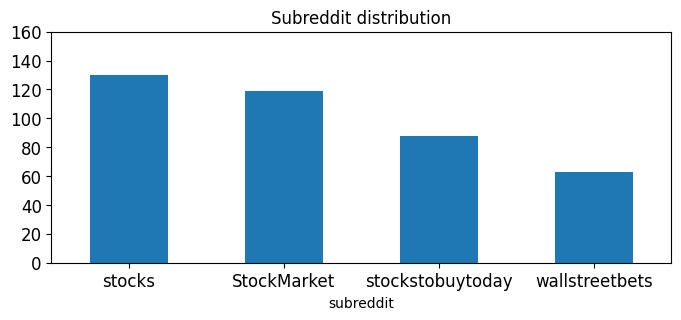

In [252]:
N_sample.subreddit.value_counts().plot(kind = 'bar',
                                       title = 'Subreddit distribution',
                                       ylim = [0, N_sample.subreddit.value_counts().max()+30], 
                                       rot = 0, fontsize = 12, figsize = (8,3))

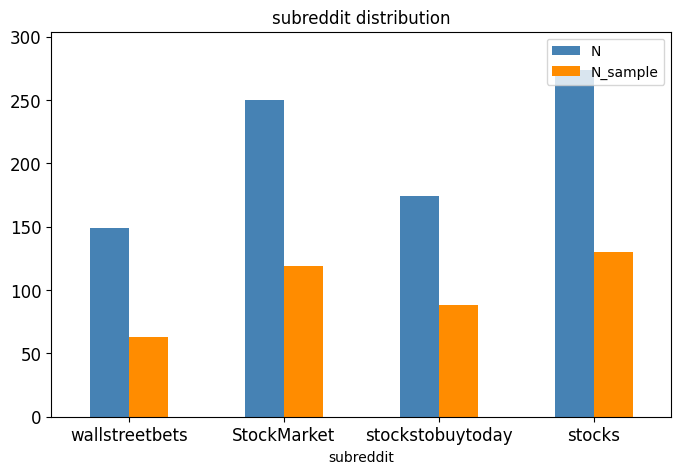

In [253]:
subreddit_order = N['subreddit'].unique()
counts_df = pd.DataFrame({
    'Full': N['subreddit'].value_counts().reindex(subreddit_order, fill_value=0),
    'Sample': N_sample['subreddit'].value_counts().reindex(subreddit_order, fill_value=0)
}).fillna(0)

ax = counts_df.plot(kind='bar', figsize=(8,5), rot=0, fontsize=12,color = ['steelblue','darkorange'])
plt.title('subreddit distribution')
plt.ylim(0, counts_df.values.max() + 30)  
ax.legend(['N', 'N_sample'], title="", loc="upper right")
plt.show()

## The different between analyze() and fit_transform → nonzero
analyze(N.text[0]) → What exact tokens (with duplicates) come out of preprocessing? 

fit_transform + nonzero → Which unique words from the vocabulary appear in this document?

In [254]:
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer()
analyze = count_vect.build_analyzer()
analyze(N.text[1])

['stunt',
 'as',
 'in',
 'like',
 'why',
 'did',
 'they',
 'even',
 'make',
 'big',
 'deal',
 'about',
 'starting',
 'it',
 'in',
 'the',
 'first',
 'place',
 'no',
 'company',
 'should',
 'ever',
 'talk',
 'about',
 'politics',
 'ever']

In [255]:
N_counts = count_vect.fit_transform(N.text) 
word_indices = N_counts[1].nonzero()[1]
word_in_doc = count_vect.get_feature_names_out()[word_indices]
print("The words that this 1 represents from the vocabulary are :\n",word_in_doc)

The words that this 1 represents from the vocabulary are :
 ['stunt' 'as' 'in' 'like' 'why' 'did' 'they' 'even' 'make' 'big' 'deal'
 'about' 'starting' 'it' 'the' 'first' 'place' 'no' 'company' 'should'
 'ever' 'talk' 'politics']


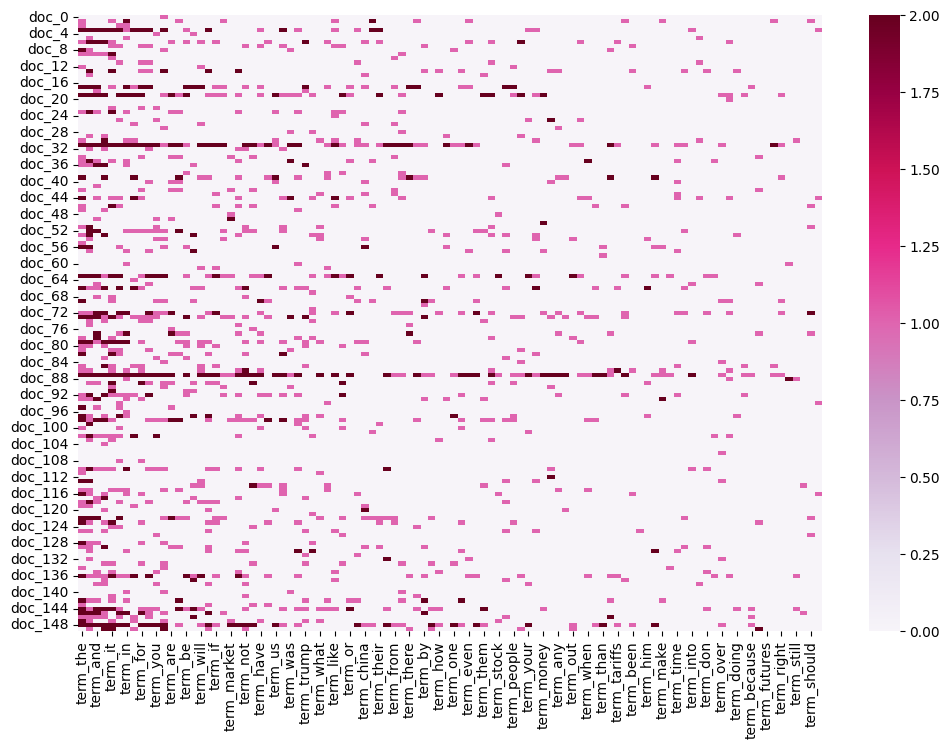

In [256]:
import seaborn as sns

# Number of documents and terms
docs = 150 
terms = 100 

#safety bounds 
n_docs, n_terms = N_counts.shape
docs  = min(docs,  n_docs)
terms = min(terms, n_terms)

# Top-N terms (efficient Top-K selection)
# sum over documents -> total frequency per term, return 1D array
term_sums = N_counts.sum(axis=0).A1
# get top-K indices in O(n) time, then sort those K by descending score
top_indices = np.argpartition(term_sums, -terms)[-terms:]
top_indices = top_indices[np.argsort(term_sums[top_indices])[::-1]]

# Rename the axis
plot_x = ["term_"+str(i) for i in count_vect.get_feature_names_out()[top_indices]]
plot_y = ["doc_"+str(i) for i in list(N.index)[:docs]]

# Create Submatrix
plot_z = N_counts[:docs, :][:, top_indices].toarray()

# DataFrame for Heatmap
df_todraw = pd.DataFrame(plot_z, columns=plot_x, index=plot_y)

# plot Heatmap 
plt.subplots(figsize=(12, 8))
ax = sns.heatmap(
    df_todraw,
    cmap="PuRd",
    vmin=0,
    vmax=np.percentile(plot_z, 99),  
    annot=False
)
plt.show()

In [257]:
import plotly.express as px

#compute the term frequency
term_counts = np.asarray(N_counts.sum(axis=0)).ravel()
feature_names = count_vect.get_feature_names_out()

#build dataframe
df = pd.DataFrame({"term": feature_names, "counts": term_counts})
df_top = df.sort_values("counts", ascending=False).head(300)

#plot horizontal bar chart
fig = px.bar(df_top.sort_values("counts"), 
             x="counts", y="term",
             orientation="h",
             title="Top 300 Term Frequencies")

fig.update_layout(yaxis=dict(autorange="reversed"))
fig.update_layout(height=1000)
fig.show()

In [258]:
import plotly.graph_objects as go

# Assume you already have df_top (Top 300 by frequency)
# Prepare: sort by frequency (desc) and create rank
df_plot = df_top.sort_values("counts", ascending=False).reset_index(drop=True)
df_plot["rank"] = np.arange(1, len(df_plot) + 1)

# 20% cutoff (k points)
k = max(1, int(np.ceil(0.2 * len(df_plot))))

fig = go.Figure()

# Yellow area for ALL points (bottom 80% + top 20% as base)
fig.add_trace(go.Scatter(
    x=df_plot["rank"], y=df_plot["counts"],
    mode="none", fill="tozeroy",
    fillcolor="rgba(255, 215, 0, 0.6)", 
    showlegend=False   # yellow
))

# Green area overlay for TOP 20% (leftmost k points)
fig.add_trace(go.Scatter(
    x=df_plot["rank"][:k], y=df_plot["counts"][:k],
    mode="none", fill="tozeroy",
    fillcolor="rgba(0, 160, 0, 0.7)",
    showlegend=False,     # green
))

fig.update_layout(
    title="Term Frequency ",
    xaxis_title="Terms",
    yaxis_title="Frequency",
    height=600,
    template="none"
)

fig.show()

## New Data Visualization
Observe how activity varies over time.

<module 'matplotlib.pyplot' from 'c:\\DM2025-Lab1\\DM2025-Lab1-Exercise\\.venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

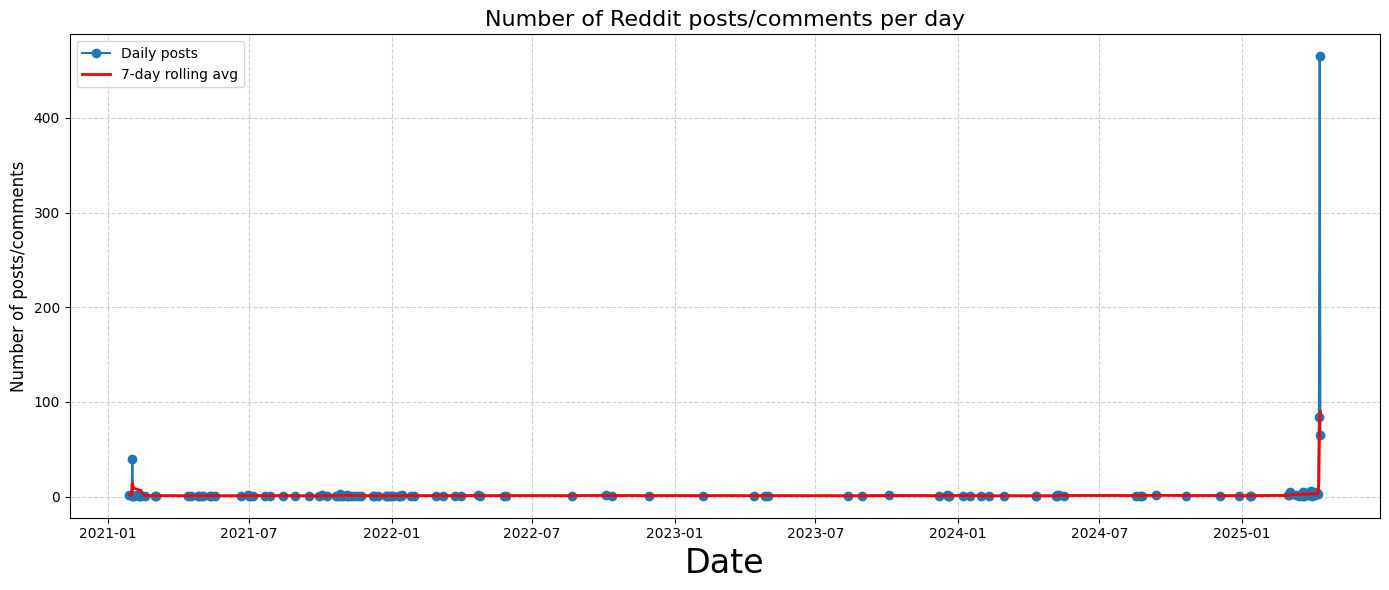

In [266]:
df = pd.read_csv('newdataset\Reddit-stock-sentiment.csv')
# Make sure the datetime column is parsed correctly
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

# Group by date to count posts per day
df['date'] = df['datetime'].dt.date
posts_per_day = df.groupby('date').size()

# Calculate 7-day rolling average 
rolling_avg = posts_per_day.rolling(window=7, min_periods=1).mean()

# Plot line chart
plt.figure(figsize=(14,6))

# Daily posts line
plt.plot(posts_per_day.index, posts_per_day.values, marker='o', linestyle='-', label="Daily posts")

# 7-day rolling average line
plt.plot(rolling_avg.index, rolling_avg.values, color='red', linewidth=2, label="7-day rolling avg")

# Titles and labels
plt.title("Number of Reddit posts/comments per day", fontsize=16)
plt.xlabel("Date", fontsize=24)
plt.ylabel("Number of posts/comments", fontsize=12)

# Add legend
plt.legend()

# Add grid lines
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent clipping
plt.tight_layout()

# Show the plot
plt


# Phase 2

In [ ]:
### Begin Assignment Here